In [2]:
# - Import the pandas library for data manipulation
import pandas as pd


In [3]:
# - Load the edge list for ego network 0
# Each row represents an anonymised pair of users who are connected (friends)
edges = pd.read_csv(
    "../facebook/0.edges",
    sep=" ",
    header=None,
    names=["source", "target"]
)

edges.head()

,source,target
0,236,186
1,122,285
2,24,346
3,271,304
4,176,9


In [4]:
# — Display the shape of the dataset
# edges.shape returns a tuple: (number_of_rows, number_of_columns)
# Each row is one friendship (connection) between two anonymised users.
# This shows how many total connections exist in this ego network.
edges.shape


(5038, 2)

In [17]:
# — Validate the edge-list data

print("Dataset structure:")
edges.info()

# Check for missing values
missing_values = edges[["source", "target"]].isnull().sum()

print("\nMissing values:")
print(missing_values)

# Check for duplicate relationships
duplicate_count = edges.duplicated().sum()

print("\nExact duplicate records:", duplicate_count)

# Check for self-loops
self_loop_count = (edges["source"] == edges["target"]).sum()

print("Self-loops:", self_loop_count)

Dataset structure:
<class 'pandas.DataFrame'>
RangeIndex: 5038 entries, 0 to 5037
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   source  5038 non-null   int64
 1   target  5038 non-null   int64
dtypes: int64(2)
memory usage: 78.8 KB

Missing values:
source    0
target    0
dtype: int64

Exact duplicate records: 0
Self-loops: 0


In [18]:
# — Summarise the data validation results

validation_summary = pd.DataFrame({
    "Validation Check": [
        "Total records",
        "Missing values",
        "Exact duplicates",
        "Self-loops",
        "Unique users"
    ],
    "Result": [
        len(edges),
        edges[["source", "target"]].isnull().sum().sum(),
        duplicate_count,
        self_loop_count,
        len(set(edges["source"]).union(edges["target"]))
    ]
})

validation_summary

,Validation Check,Result
0,Total records,5038
1,Missing values,0
2,Exact duplicates,0
3,Self-loops,0
4,Unique users,333


In [ ]:
# — Count how many unique users exist
# The edges table has two columns: 'source' and 'target'.
# A user can appear in either column, so we combine both columns.
# pd.unique(...) finds all distinct user IDs.
# len(nodes) shows how many unique users are present in this ego network.
nodes = pd.unique(edges[["source", "target"]].values.ravel())
len(nodes)


333

In [6]:
# — Find the most connected users
# To find how many connections each user has, the code combines counts how often each user ID appears.
# A user can appear in 'source' or 'target', the code combines both columns.
# value_counts() shows a list of users sorted by number of connections (degree).
# degree.head(10) shows the top 10 most connected users in this ego network.
degree = pd.concat([edges["source"], edges["target"]]).value_counts()
degree.head(10)


56     154
67     150
271    144
322    142
25     136
26     134
252    128
21     128
277    128
122    124
Name: count, dtype: int64

In [7]:
# — Create a NetworkX graph from the edges data
# NetworkX is a library used to analyse networks (graphs).
# The code creates a graph object called G.
# Then it adds all the friendship pairs (source → target) as edges in the graph.
# After this step, G becomes a full network structure that NetworkX can analyse.
import networkx as nx

G = nx.from_pandas_edgelist(edges, source="source", target="target")


In [8]:
# — Calculate basic graph statistics
# G.number_of_nodes() shows how many unique users are in the network.
# G.number_of_edges() shows how many friendship connections exist.
# max(dict(nx.degree(G)).values()) finds the highest degree (most connected user).
# These statistics help us understand the size and structure of the network.
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
degrees = dict(G.degree())
max_degree = max(degrees.values())

num_nodes, num_edges, max_degree


(333, 2519, 77)

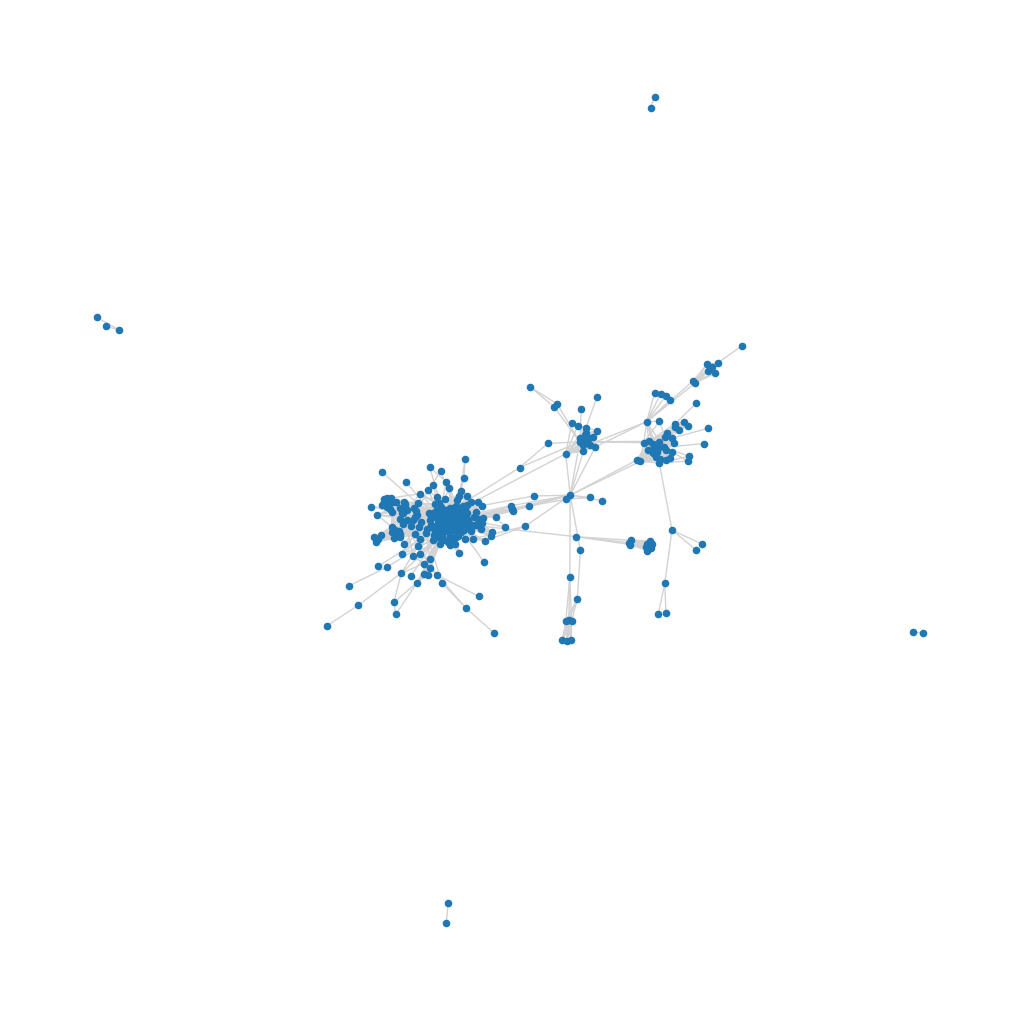

In [9]:
# — Visualise the network using NetworkX
# nx.spring_layout(G) calculates positions for each node so the graph looks readable.
# plt.figure() creates a blank canvas for the plot.
# nx.draw() draws the nodes and edges of the network.
# node_size controls how big each user appears.
# edge_color sets the colour of the connections.
# This visualisation helps us see the structure of the ego network.
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, node_size=20, edge_color="lightgray")
plt.show()


In [10]:
# — Descriptive statistics for the ego network

# Average degree (average number of connections per user)
avg_degree = sum(dict(G.degree()).values()) / num_nodes

# Median degree
import numpy as np
median_degree = np.median(list(dict(G.degree()).values()))

# Degree distribution (list of all degrees)
degree_values = list(dict(G.degree()).values())

# Number of connected components
num_components = nx.number_connected_components(G)

# Size of the largest connected component
largest_component = max(nx.connected_components(G), key=len)
largest_component_size = len(largest_component)

num_nodes, num_edges, avg_degree, median_degree, num_components, largest_component_size


(333, 2519, 15.12912912912913, np.float64(10.0), 5, 324)

In [11]:
# — Degree distribution for the ego network
# The degree of a node represents the number of direct connections it has.
# This distribution provides an overview of how connectivity varies across users.
degree_sequence = [G.degree(n) for n in G.nodes()]
degree_sequence[:10], len(degree_sequence)


([36, 43, 62, 46, 15, 26, 72, 54, 13, 56], 333)

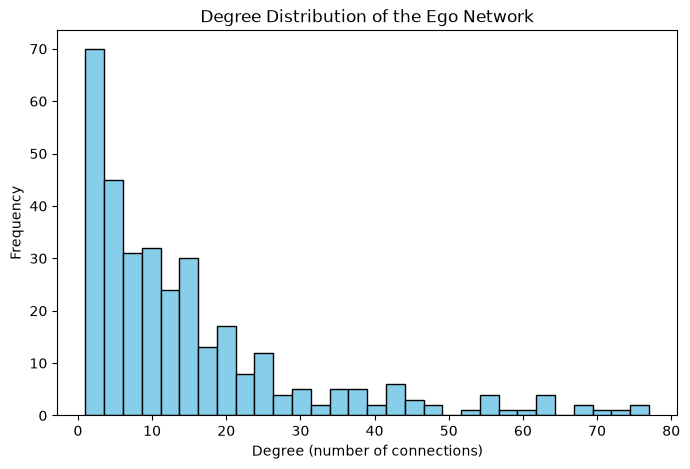

In [12]:
# — Degree distribution histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=30, color="skyblue", edgecolor="black")
plt.title("Degree Distribution of the Ego Network")
plt.xlabel("Degree (number of connections)")
plt.ylabel("Frequency")
plt.show()




In [13]:
# — Centrality Measures for the Ego Network

# Degree centrality: users with the most direct connections
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality: users who act as bridges between groups
betweenness_centrality = nx.betweenness_centrality(G)

# Closeness centrality: users closest to all others in terms of distance
closeness_centrality = nx.closeness_centrality(G)

# Eigenvector centrality: users connected to other influential users
eigenvector_centrality = nx.eigenvector_centrality(G)

# Clustering coefficient: measures how connected each user's neighbours are to one another
clustering_coefficient = nx.clustering(G)

# Average clustering coefficient: measures the overall tendency of users in the network
# to form closely connected groups
average_clustering = nx.average_clustering(G)

# Display the average clustering coefficient
print("Average clustering coefficient:", average_clustering)

# Show top 10 for each measure
import pandas as pd

centrality_df = pd.DataFrame({
    "degree": degree_centrality,
    "betweenness": betweenness_centrality,
    "closeness": closeness_centrality,
    "eigenvector": eigenvector_centrality,
    "clustering_coefficient": clustering_coefficient
})

centrality_df.sort_values("degree", ascending=False).head(10)


Average clustering coefficient: 0.5082445417696636


,degree,betweenness,closeness,eigenvector,clustering_coefficient
56,0.231928,0.019714,0.369264,0.198145,0.331511
67,0.225904,0.017708,0.372327,0.197438,0.344144
271,0.216867,0.014974,0.368399,0.193678,0.369718
322,0.213855,0.043159,0.376340,0.159753,0.271630
25,0.204819,0.085363,0.380902,0.154776,0.267340
26,0.201807,0.009570,0.364552,0.186401,0.393487
21,0.192771,0.033100,0.365400,0.160469,0.328373
277,0.192771,0.265858,0.413479,0.162030,0.325893
252,0.192771,0.010658,0.361200,0.177161,0.384425
122,0.186747,0.022754,0.362868,0.165014,0.365415


In [14]:
# — Community Detection using Greedy Modularity

from networkx.algorithms.community import greedy_modularity_communities

# Detect communities
communities = greedy_modularity_communities(G)

# Convert to list of lists for readability
community_list = [list(c) for c in communities]

# Number of communities
num_communities = len(community_list)

# Sizes of each community
community_sizes = [len(c) for c in community_list]

num_communities, community_sizes


(12, [119, 52, 47, 38, 27, 23, 10, 8, 3, 2, 2, 2])

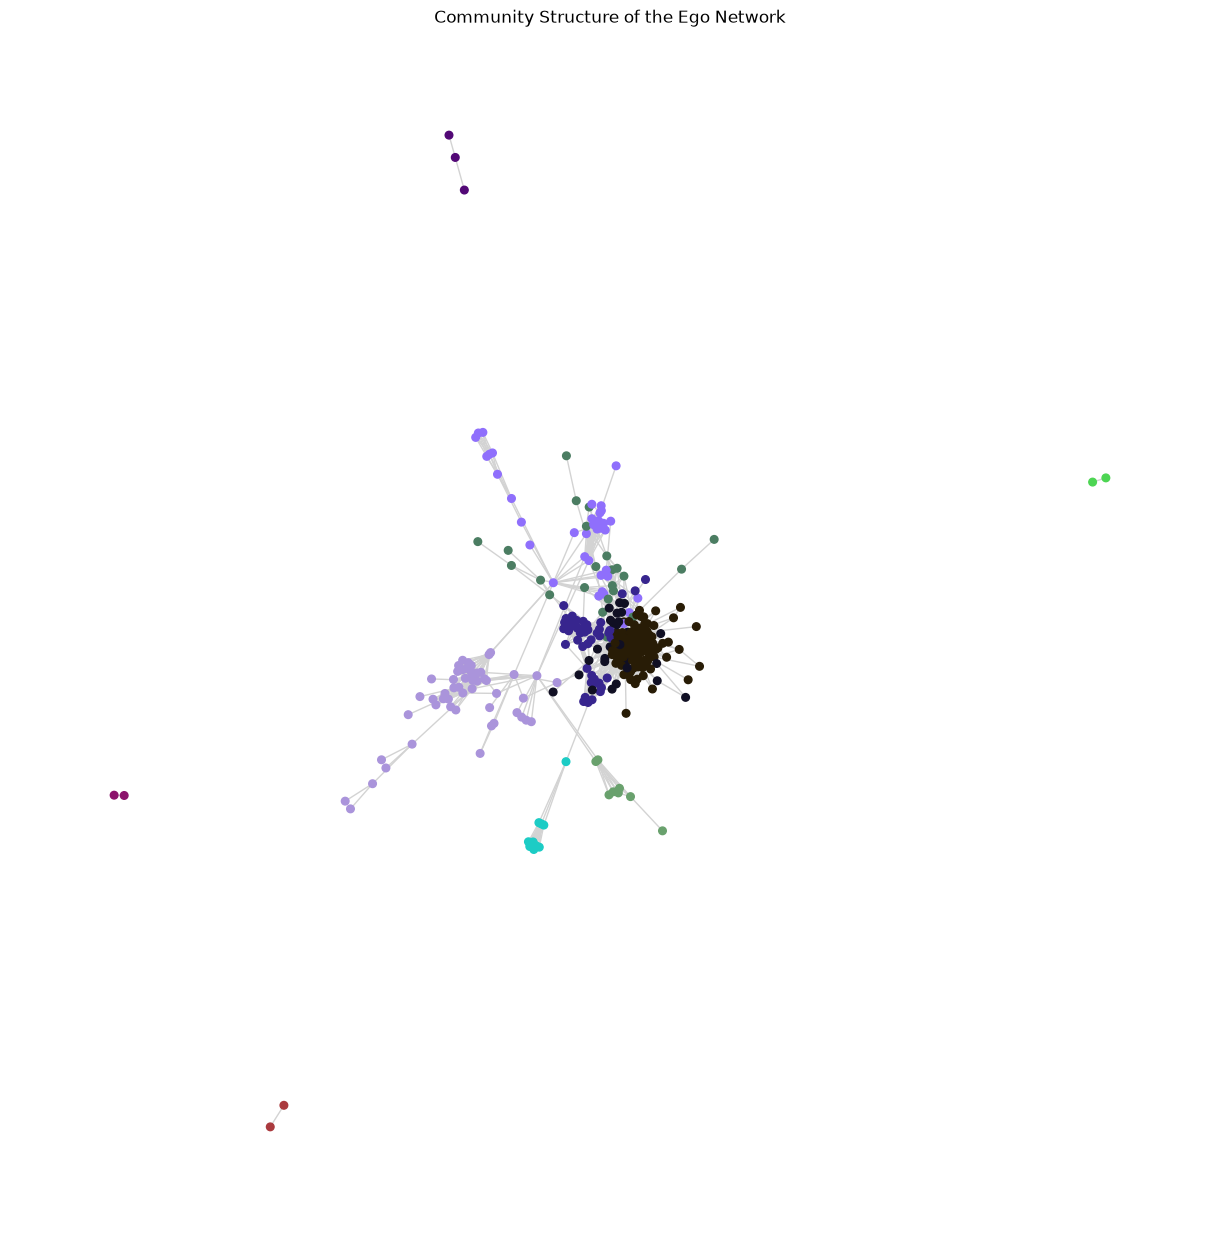

In [15]:
# — Visualise communities with different colours (SciPy-free version)

import matplotlib.pyplot as plt
import random

# Assign each community a random colour
color_map = {}
for i, community in enumerate(community_list):
    colour = (random.random(), random.random(), random.random())
    for node in community:
        color_map[node] = colour

# Create a list of colours for each node
node_colors = [color_map[node] for node in G.nodes()]

# Use spring layout (does NOT require SciPy)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 12))
nx.draw(G, pos, node_color=node_colors, node_size=30, edge_color="lightgray")
plt.title("Community Structure of the Ego Network")
plt.show()


In [16]:
# — Link prediction using Common Neighbours, Jaccard Coefficient, and Adamic–Adar
# These algorithms estimate the likelihood of future connections based on existing network structure.

from networkx.algorithms.link_prediction import jaccard_coefficient, adamic_adar_index
from networkx import common_neighbors

# Convert the graph to a simple undirected form if required
G_simple = nx.Graph(G)

# Jaccard Coefficient
jaccard_preds = list(jaccard_coefficient(G_simple))

# Adamic–Adar Score
adamic_preds = list(adamic_adar_index(G_simple))

# Common Neighbours
non_edges = nx.non_edges(G_simple)
common_preds = [(u, v, len(list(common_neighbors(G_simple, u, v)))) for u, v in non_edges]

# Convert predictions to DataFrames
df_jaccard = pd.DataFrame(jaccard_preds, columns=["u", "v", "jaccard"])
df_adamic = pd.DataFrame(adamic_preds, columns=["u", "v", "adamic_adar"])
df_common = pd.DataFrame(common_preds, columns=["u", "v", "common_neighbours"])

# Identify the highest-scoring predicted links
top_jaccard = df_jaccard.sort_values("jaccard", ascending=False).head(10)
top_adamic = df_adamic.sort_values("adamic_adar", ascending=False).head(10)
top_common = df_common.sort_values("common_neighbours", ascending=False).head(10)

top_jaccard, top_adamic, top_common


(         u    v   jaccard
 24619   97  253  1.000000
 13415   52  205  1.000000
 28014  112  293  1.000000
 22847   90  145  1.000000
 47775  241  255  1.000000
 40494  180  330  0.789474
 463      2  162  0.777778
 27481  110  201  0.750000
 43400  201  245  0.750000
 43418  201  264  0.750000,
          u    v  adamic_adar
 43678  203  252    13.755288
 6322    25  315     9.211231
 6311    25  304     9.163925
 2717     9  239     9.142030
 33869  142  304     8.088548
 14529   56  280     8.008586
 5018    21  113     7.984266
 5151    21  285     7.840689
 6187    25  142     7.682307
 52487  322  332     7.621951,
          u    v  common_neighbours
 43678  203  252                 48
 6311    25  304                 33
 2717     9  239                 33
 6322    25  315                 31
 14529   56  280                 30
 5151    21  285                 30
 33869  142  304                 30
 5018    21  113                 29
 6187    25  142                 29
 29281  119